In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
from scipy.special import gamma as gamma_func
from scipy.optimize import brentq
plt.rc('axes', prop_cycle=plt.cycler(color=plt.get_cmap('Set1').colors))

In [2]:
config = {
    "data": {
        "parameter_range": (0, 10),
        "std": 1,
        #"likelihood_prior_sampling_ratio": 1,
        "n_parameters": 1,
        "n_train": 70_000,
        "n_test": 15_000,
        "n_validation": 15_000
    },
    "classifier": {
        "n_inputs": 1,
        "n_hidden_layers": 3,
        "n_units": 64
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 128,
        "n_epochs": 5
    }
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)


#### Prior Distirbutions:

In [3]:
def normalize(function, lower, upper):
    x = np.linspace(lower, upper, 1000)
    integral = np.trapezoid(function(x), x)
    def result_fct(z): return function(z) / integral
    result_fct.__name__ = function.__name__
    return result_fct

def uniform(x, min_val=0, max_val=10):
    return 1 / (max_val - min_val) if min_val <= x <= max_val else 0.

def normal(x, mean=5, std=4):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

def exponential(x, lam=.3):
    return lam * np.exp(-lam * x) if x >= 0 else 0.

def gamma(x, shape=2, scale=2):
    return (x ** (shape - 1) * np.exp(-x / scale)) / (scale ** shape * gamma_func(shape)) if x >= 0 else 0.

def sinusoidal(x, frequency=3, offset=5):
    return np.sin(frequency * x) + offset

priors = [uniform, normal, exponential, gamma, sinusoidal]
priors = [normalize(np.vectorize(f), *config["data"]["parameter_range"]) for f in priors]

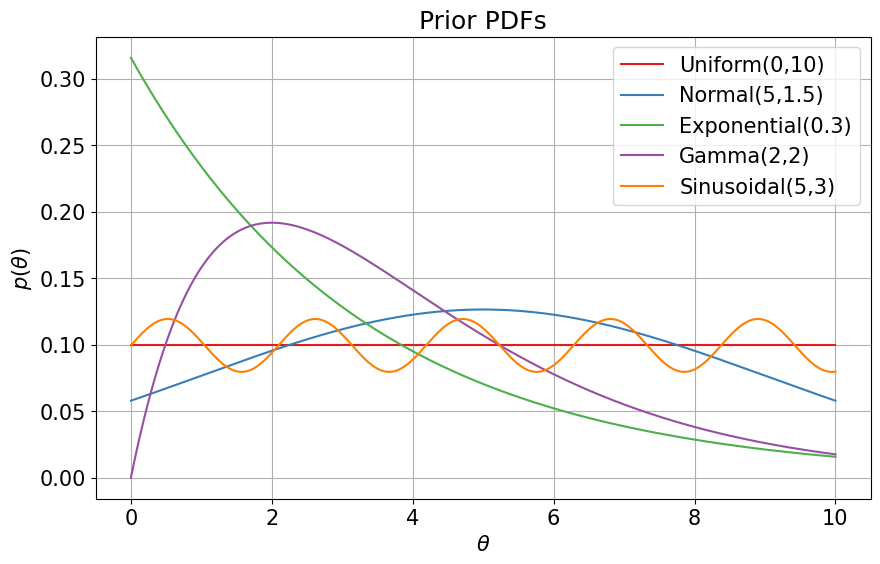

In [4]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(config["data"]["parameter_range"][0], config["data"]["parameter_range"][1], 1000)
prior_labels = ["Uniform(0,10)", "Normal(5,1.5)", "Exponential(0.3)", "Gamma(2,2)", "Sinusoidal(5,3)"]
for prior, label in zip(priors, prior_labels):
    ax.plot(x, prior(x), label=label)
ax.legend()
ax.set_title("Prior PDFs")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("$p(\\theta)$")
ax.grid()
fig.savefig("figs/toy_priors.svg")
pass

In [5]:
# check normalization of priors
x = np.linspace(config["data"]["parameter_range"][0], config["data"]["parameter_range"][1], 1000)
for prior in priors:
    print(f"Integral of {prior.__name__}: {np.trapezoid(prior(x), x)}")

Integral of uniform: 1.0
Integral of normal: 1.0
Integral of exponential: 1.0
Integral of gamma: 1.0
Integral of sinusoidal: 1.0


#### Data:

In [6]:
def sample_from_pdf(pdf, n_samples, x_min, x_max):
    x_values = np.linspace(x_min, x_max, int(1e4))
    pdf_values = pdf(x_values)
    cdf_values = np.cumsum(pdf_values)
    cdf_values /= cdf_values[-1]

    random_values = generator.uniform(0, 1, n_samples)
    sampled_x = np.interp(random_values, cdf_values, x_values)
    return sampled_x

def get_data(prior, show_output=True):
    data_config = config["data"]
    total_data_points = data_config["n_train"] + data_config["n_test"] + data_config["n_validation"]
    n_class = total_data_points // 2

    #labels
    labels = np.hstack((np.zeros(n_class), np.ones(n_class)))

    #parameters
    #parameters_all = generator.uniform(low=data_config["parameter_range"][0], high=data_config["parameter_range"][1], size=3*n_class)
    parameters_all = sample_from_pdf(prior, 3*n_class, data_config["parameter_range"][0], data_config["parameter_range"][1])
    parameters_dependent = parameters_all[:n_class]
    parameters_independent = parameters_all[n_class:2*n_class]
    parameters_random = parameters_all[2*n_class:]
    parameters = np.hstack((parameters_independent, parameters_dependent))

    #data
    data_0 = generator.normal(loc=parameters_random, scale=data_config["std"], size=n_class)
    data_1 = generator.normal(loc=parameters_dependent, scale=data_config["std"], size=n_class)
    data = np.hstack((data_0, data_1))

    #shuffle:
    idx = np.arange(2*(n_class))
    generator.shuffle(idx)
    data, labels, parameters = [torch.tensor(x[idx]).float() for x in (data, labels, parameters)]

    #split:
    n_train, n_test, n_validation = data_config["n_train"], data_config["n_test"], data_config["n_validation"]
    all_information = (data, labels, parameters)
    data_train, labels_train, parameters_train, = [x[:n_train] for x in all_information]
    data_test, labels_test, parameters_test, = [x[n_train:n_train+n_test] for x in all_information]
    data_validation, labels_validation, parameters_validation, = [x[n_train+n_test:n_train+n_test+n_validation] for x in all_information]

    if show_output:
        print(f"Train: {data_train.shape}, {labels_train.shape}, {parameters_train.shape}")
        print(f"Test: {data_test.shape}, {labels_test.shape}, {parameters_test.shape}")
        print(f"Validation: {data_validation.shape}, {labels_validation.shape}, {parameters_validation.shape}")
    
    return (data_train, parameters_train, labels_train), (data_validation, parameters_validation, labels_validation), (data_test, parameters_test, labels_test)

#### Classifier:

In [7]:
class BinaryClassifier(nn.Module):
    def __init__(self, n_inputs):
        super(BinaryClassifier, self).__init__()
        input_layer = [nn.Linear(n_inputs, config["classifier"]["n_units"]), nn.ReLU()]
        hidden_layers = []
        for _ in range(config["classifier"]["n_hidden_layers"]):
            hidden_layers += [nn.Linear(config["classifier"]["n_units"], config["classifier"]["n_units"]), nn.ReLU()]
        output_layer = [nn.Linear(config["classifier"]["n_units"], 1), nn.Sigmoid()]
        self.model = nn.Sequential(*(input_layer + hidden_layers + output_layer))    
        
    def forward(self, x):
        return self.model(x)

#### Training:

In [8]:
def train(model, data_train, parameters_train, labels_train, data_validation, parameters_validation, labels_validation, show_output=True):    
    model.to(device)
    
    train_dataset = torch.utils.data.TensorDataset(data_train, parameters_train, labels_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config["training"]["batch_size"], shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    criterion = nn.BCELoss()
    
    results = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_auc": []
    }
    
    for epoch in range(config["training"]["n_epochs"]):
        model.train()
        epoch_loss = 0
        for batch_data, batch_parameters, batch_labels in train_loader:
            batch_data, batch_parameters, batch_labels = [x.to(device).unsqueeze(1) for x in (batch_data, batch_parameters, batch_labels)]
            inputs = torch.cat((batch_data, batch_parameters), dim=1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        results["train_loss"] += [epoch_loss / len(train_loader)]
        
        model.eval()
        with torch.no_grad():
            val_data, val_parameters, val_labels = [x.to(device).unsqueeze(1) for x in (data_validation, parameters_validation, labels_validation)]
            val_inputs = torch.cat((val_data, val_parameters), dim=1)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            val_accuracy = ((val_outputs >= 0.5).float() == val_labels).float().mean()
            val_auc = roc_auc_score(val_labels.cpu(), val_outputs.cpu())

        results["val_loss"] += [val_loss.item()]
        results["val_accuracy"] += [val_accuracy.item()]
        results["val_auc"] += [val_auc]
        if show_output: print(f"Epoch {epoch+1}/{config['training']['n_epochs']}, Loss: {results["train_loss"][-1]}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_accuracy.item():.4f}, Val AUC: {val_auc:.4f}")
                
    return model, results

#### Testing:

In [9]:
def test_model(model, data_test, parameters_test, labels_test, show_output=True):
    with torch.no_grad():
        model.eval()
        data_test, parameters_test, labels_test = [x.to(device).unsqueeze(1) for x in (data_test, parameters_test, labels_test)]
        inputs = torch.cat((data_test, parameters_test), dim=1)
        outputs = model(inputs)
        test_loss = nn.BCELoss()(outputs, labels_test)
        test_accuracy = ((outputs >= 0.5).float() == labels_test).float().mean()
        test_auc = roc_auc_score(labels_test.cpu(), outputs.cpu())
    if show_output: print(f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_accuracy.item():.4f}, Test AUC: {test_auc:.4f}")
    return test_loss.item(), test_accuracy.item(), test_auc

#### Plots:

In [10]:
def plot_training(results, title):
    plt.rcParams.update({'font.size': 8})
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    ax[0].plot(results["train_loss"], label="Train Loss")
    ax[0].plot(results["val_loss"], label="Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_ylim(0.2, 0.5)
    ax[0].set_title(title)
    ax[0].legend()
    ax[1].plot(results["val_accuracy"], label="Validation Accuracy")
    ax[1].plot(results["val_auc"], label="Validation AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Metric")
    ax[1].set_ylim(0.7, 1)
    ax[1].set_title(title)
    ax[1].legend()
    plt.tight_layout()

def plot_prior_per_parameter(all_posteriors: dict, parameters_post, data_inputs):
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(all_posteriors)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, posteriors) in enumerate(all_posteriors.items()):
        j = i // ncols
        k = i % ncols
        for posterior, data_fixed in zip(posteriors, data_inputs):
            ax[j][k].plot(parameters_post, posterior, label=f"x={data_fixed:.2f}, $x_m=${parameters_post[np.argmax(posterior)]:.2f}")
            ax[j][k].axvline(data_fixed, color='k', linestyle='--', alpha=0.5)
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("$\\theta$")
        ax[j][k].set_ylabel("$p(\\theta |x)$")
        ax[j][k].legend(loc='lower center')
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()

def plot_parameter_per_prior(all_posteriors: dict, parameters_post, data_inputs):
    plt.rcParams.update({'font.size': 10})
    n_inputs = len(data_inputs)
    ncols = min(3, n_inputs)
    nrows = (n_inputs + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    pretty = dict(zip(all_posteriors.keys(), prior_labels)) if 'prior_labels' in globals() else {k: k for k in all_posteriors}

    for i, x0 in enumerate(data_inputs):
        a = axes[i]
        for prior_name, posts in all_posteriors.items():
            p = posts[i]
            x_map = parameters_post[np.argmax(p)]
            a.plot(parameters_post, p, label=f"{pretty[prior_name]} (MAP={x_map:.2f})")
        a.axvline(x0, color='k', linestyle='--', alpha=0.5)
        a.set_title(f"x = {x0:.2f}")
        a.set_xlabel("$\\theta$")
        a.set_ylabel("$p(\\theta\\mid x)$")
        a.grid(True)
        a.legend(loc='lower center')

    for k in range(n_inputs, nrows * ncols):
        fig.delaxes(axes[k])
    

def plot_errorbars(HPDs: dict, data_inputs, all_posteriors, parameters_post):
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(HPDs)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, errors) in enumerate(HPDs.items()):
        j = i // ncols
        k = i % ncols

        # MAP estimates from the posteriors for this prior
        posts = all_posteriors[prior_name]
        y_hat = np.asarray([parameters_post[np.argmax(p)] for p in posts])

        # Build asymmetric yerr arrays (2, N): [lower, upper]
        yerr68_lower, yerr68_upper = [], []
        yerr95_lower, yerr95_upper = [], []

        def pick_interval(intervals, yh):
            if intervals is None or len(intervals) == 0:
                return np.array([yh, yh])
            intervals = np.atleast_2d(intervals)
            mask = (intervals[:, 0] <= yh) & (yh <= intervals[:, 1])
            if np.any(mask):
                return intervals[np.where(mask)[0][0]]
            mids = 0.5 * (intervals[:, 0] + intervals[:, 1])
            idx_min = np.argmin(np.abs(mids - yh))
            return intervals[idx_min]

        for idx, e in enumerate(errors):
            yh = y_hat[idx]
            low68, high68 = pick_interval(e["68"], yh)
            low95, high95 = pick_interval(e["95"], yh)
            yerr68_lower.append(yh - low68)
            yerr68_upper.append(high68 - yh)
            yerr95_lower.append(yh - low95)
            yerr95_upper.append(high95 - yh)

        yerr68 = np.vstack([yerr68_lower, yerr68_upper])
        yerr95 = np.vstack([yerr95_lower, yerr95_upper])

        # Plot 95% HPD first (behind), then 68% HPD on top
        ax[j][k].errorbar(data_inputs, y_hat, yerr=yerr95, fmt='o', color='C0', ecolor='C0', alpha=0.35, capsize=5, label="95% HPD")
        ax[j][k].errorbar(data_inputs, y_hat, yerr=yerr68, fmt='o', color='C0', ecolor='C0', capsize=5, label="68% HPD")

        # Ideal y = x line
        ax[j][k].plot([data_inputs[0]-1, data_inputs[-1]+1], [data_inputs[0]-1, data_inputs[-1]+1], 'k--', label="Ideal")
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("True $\\theta$")
        ax[j][k].set_ylabel("Estimated $\\theta$")
        ax[j][k].legend()
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()

#### Run:

Tests for uniform prior: Test Loss: 0.4040, Test Acc: 0.8149, Test AUC: 0.8694
Tests for normal prior: Test Loss: 0.4267, Test Acc: 0.7982, Test AUC: 0.8555
Tests for exponential prior: Test Loss: 0.4705, Test Acc: 0.7599, Test AUC: 0.8316
Tests for gamma prior: Test Loss: 0.4614, Test Acc: 0.7708, Test AUC: 0.8383
Tests for sinusoidal prior: Test Loss: 0.4181, Test Acc: 0.8019, Test AUC: 0.8596


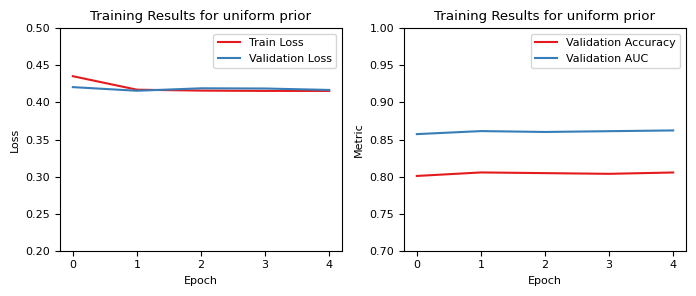

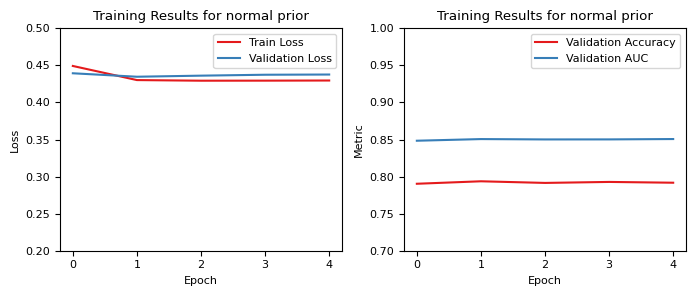

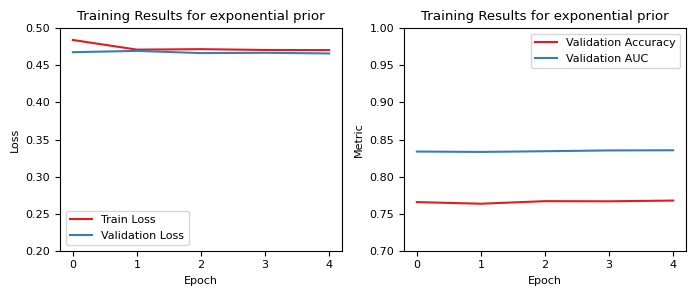

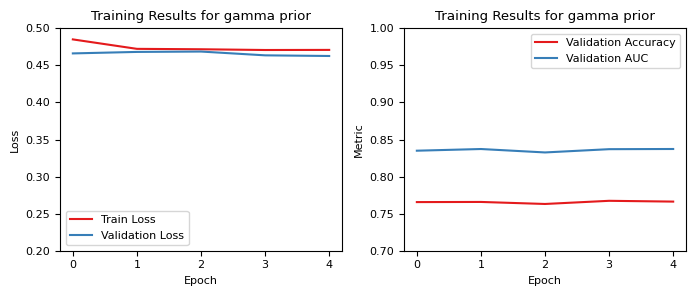

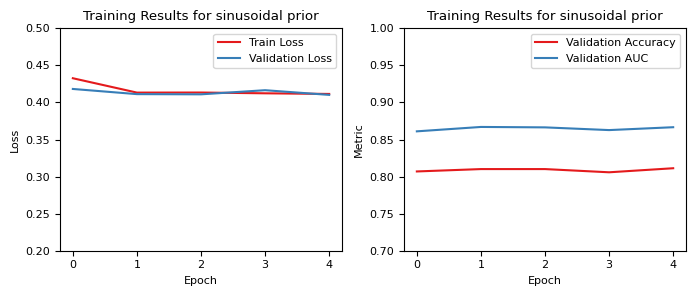

In [11]:
models = []
for prior in priors:
    train_set, validation_set, test_set = get_data(prior=prior, show_output=False)
    model = BinaryClassifier(n_inputs=config["classifier"]["n_inputs"]+config["data"]["n_parameters"])
    model, training_results = train(model, *train_set, *validation_set, show_output=False)
    plot_training(training_results, f"Training Results for {prior.__name__} prior")
    print (f"Tests for {prior.__name__} prior: ", end="")
    test_results = test_model(model, *test_set)
    models += [model]
    

#### Posterior:

In [12]:
def calculate_posteriors(model, prior, data_points, parameters_post):
    posteriors = []    
    for data_fixed in data_points:
        data_post = np.full(len(parameters_post), data_fixed)
        input_post = torch.cat(
            tensors=[torch.tensor(x).float().to(device).unsqueeze(1) for x in (data_post, parameters_post)],
            dim=1
        )
        ratios = model(input_post).cpu().detach().numpy().flatten()
        posterior = ratios * prior(parameters_post)
        posteriors += [posterior / np.trapezoid(posterior, parameters_post)]
    return posteriors

def area_above_k(k, theta, posterior_normalized):
    mask = posterior_normalized >= k
    if not np.any(mask):
        return 0.0
    area = np.trapezoid(posterior_normalized[mask], theta[mask])
    return area

def compute_hpd_interval(theta, posterior_normalized, alpha):
    def root_func(k):
        return area_above_k(k, theta, posterior_normalized) - (1 - alpha)
    # The posterior density values range from p_min to p_max
    p_min = np.min(posterior_normalized)
    p_max = np.max(posterior_normalized)
    # Ensure that func(k_lower) >= 0 and func(k_upper) <= 0
    k_lower = p_min
    k_upper = p_max
    # Adjust the bounds if necessary
    func_lower = root_func(k_lower)
    func_upper = root_func(k_upper)
    if func_lower < 0 or func_upper > 0:
        raise ValueError("Cannot find a valid k in the given range. Check the posterior and alpha.")
    # Use brentq to find k
    k = brentq(root_func, k_lower, k_upper, xtol=1e-12)
    # Identify the intervals where posterior >= k
    mask = posterior_normalized >= k
    indices = np.where(mask)[0]
    # Find contiguous intervals and store them in a NumPy array
    intervals = []
    if indices.size > 0:
        # Identify breaks in the sequence of indices
        breaks = np.where(np.diff(indices) > 1)[0]
        start_idx = 0
        breaks = np.append(breaks, len(indices) - 1)
        for break_idx in breaks:
            idx_range = indices[start_idx:break_idx + 1]
            theta_start = theta[idx_range[0]]
            theta_end = theta[idx_range[-1]]
            intervals.append([theta_start, theta_end])
            start_idx = break_idx + 1
    else:
        intervals = []
    # Convert intervals to a NumPy array
    intervals_array = np.array(intervals)
    return intervals_array

n_posterior, n_parameters, data_is_random = 3, int(1e4), False
param_min, param_max = config["data"]["parameter_range"]
param_range = param_max - param_min
if data_is_random:
    data_inputs = generator.normal(
        loc=generator.uniform(
            low=param_min+param_range/4,
            high=param_max-param_range/4,
            size=n_posterior
        ),
        scale=config["data"]["std"],
        size=n_posterior
    )
else:
    data_inputs = np.linspace(param_min+param_range/4, param_max-param_range/4, n_posterior)

all_posteriors = {}
all_HPDs = {}
parameters_post = np.linspace(param_min, param_max, n_parameters)
for model, prior in zip(models, priors):
    posteriors = calculate_posteriors(
        model,
        prior,
        data_inputs,
        parameters_post
    )
    errors = []
    for posterior in posteriors:
        hpd_68 = compute_hpd_interval(
            parameters_post,
            posterior,
            alpha=0.32
        )
        hpd_95 = compute_hpd_interval(
            parameters_post,
            posterior,
            alpha=0.05
        )
        errors += [{"68": hpd_68, "95": hpd_95}]
    all_HPDs[prior.__name__] = errors
    all_posteriors[prior.__name__] = posteriors

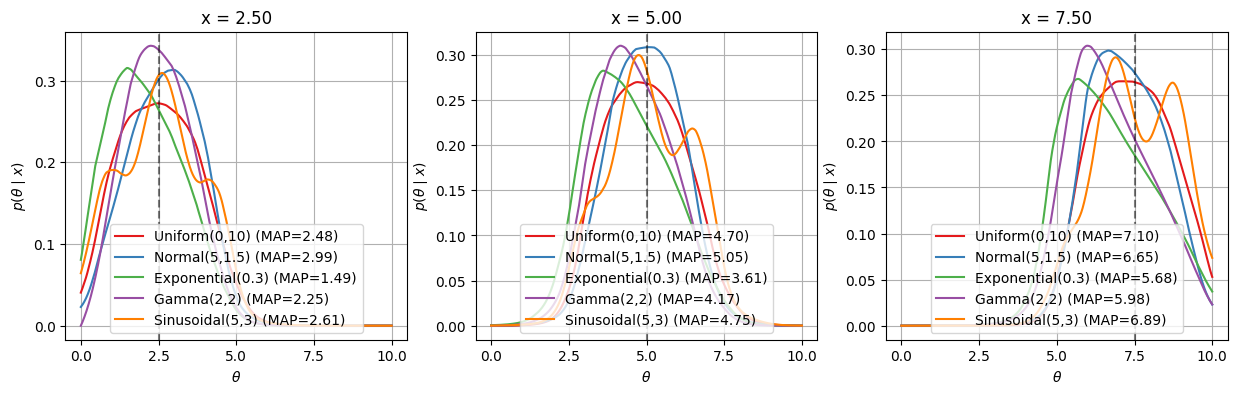

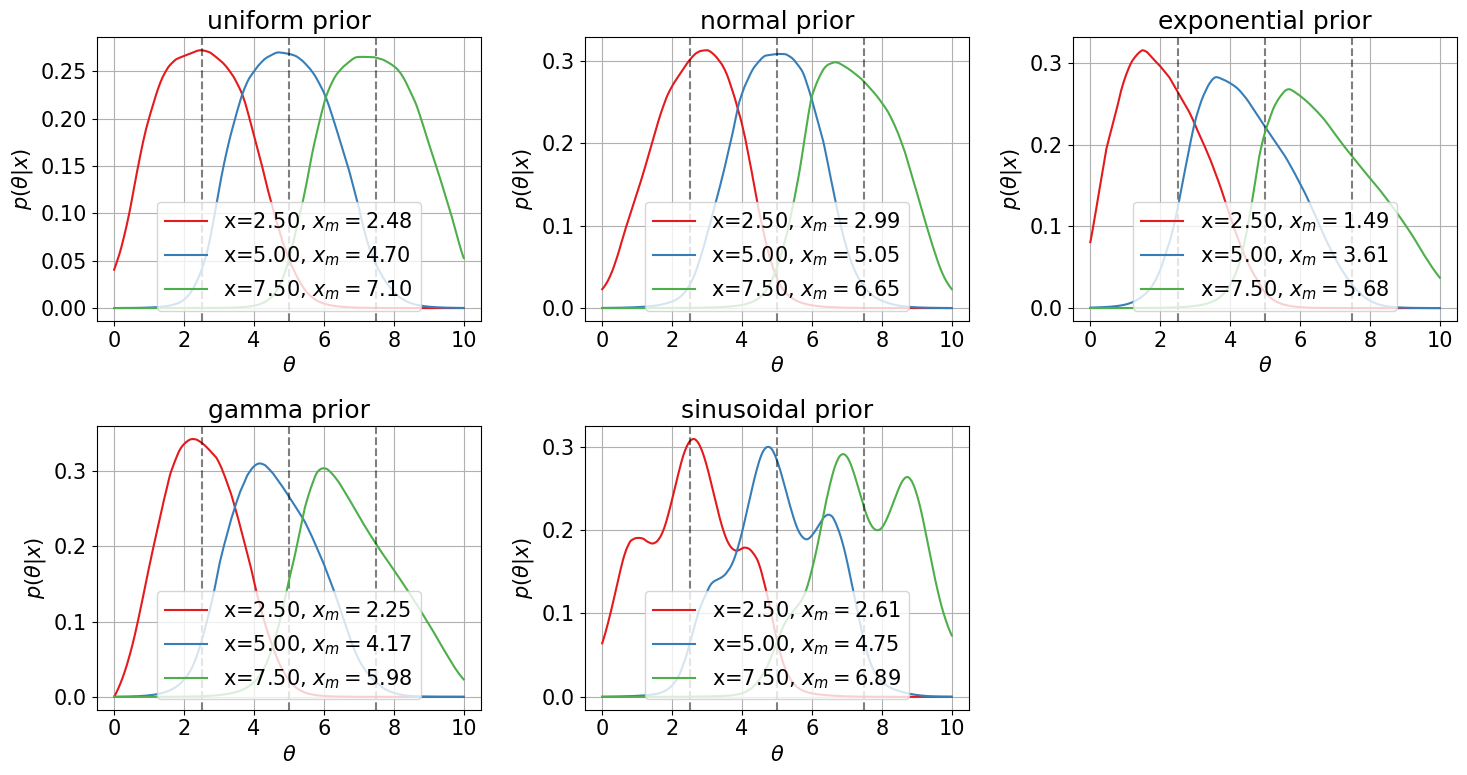

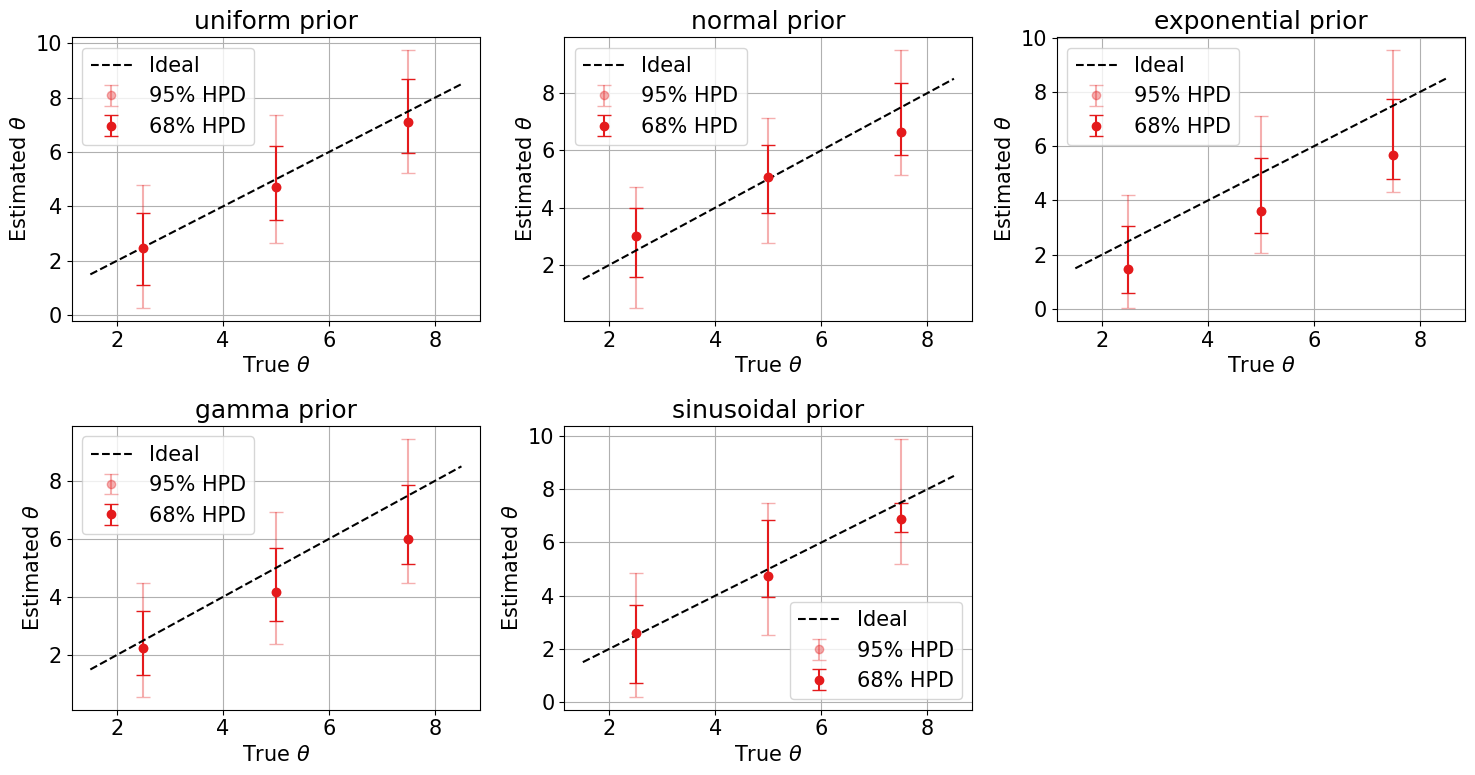

In [13]:
plot_parameter_per_prior(all_posteriors, parameters_post, data_inputs)
plot_prior_per_parameter(all_posteriors, parameters_post, data_inputs)
plot_errorbars(all_HPDs, data_inputs, all_posteriors, parameters_post)